In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [3]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [4]:

# # Load dataset
gauging_df = pd.read_csv("D:\\Thesis\\Project\\Data\\gauging_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(gauging_df),
    "Total Columns": len(gauging_df.columns),
    "Zero Values": (gauging_df == 0).sum().sum(),
    "NaN Values": gauging_df.isna().sum().sum(),
    "Blank Strings": (gauging_df == "").sum().sum(),
    "Unknown Strings": (gauging_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,1779379
1,Total Columns,6
2,Zero Values,3776
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [5]:
gauging_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,89940PG,Q,Portata,m³/s,2025-01-01 00:00:00,72.904
1,89940PG,Q,Portata,m³/s,2024-12-31 23:30:00,70.077
2,89940PG,Q,Portata,m³/s,2024-12-31 23:00:00,71.957
3,89940PG,Q,Portata,m³/s,2024-12-31 22:30:00,75.775
4,89940PG,Q,Portata,m³/s,2024-12-31 22:00:00,79.671


In [6]:
gauging_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1779379 entries, 0 to 1779378
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 81.5+ MB


In [7]:
gauging_df.describe()

,value
count,1.779379e+06
mean,4.807447e+01
std,1.236863e+03
min,-9.750000e+05
25%,3.600000e+00
50%,9.990000e+00
75%,3.400000e+01
max,5.043200e+04


In [8]:
# Preview data
print("🔍 Shape:", gauging_df.shape)

🔍 Shape: (1779379, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", gauging_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [10]:
unique_values = gauging_df['sensor_code'].unique()
unique_values

array(['Q', 'W', 'WT', 'SSTF', 'W.ABST'], dtype=object)

In [11]:
unique_values1 = gauging_df['station_code'].unique()
unique_values1

array(['89940PG', '08155PG', '19850PG', '29850PG', '59450PG', '64550PG',
       '67350PG', '69790PG', '85550PG', '05950PG', '37230PG', '61050PG',
       '82910PG', '73950PG', '22950PG', '03750PG', '42850PG', '51450PG',
       '20750PG', '26950PG', '57150PG', '79770GW', '83070GW', '27020GW',
       '27001GW', '27010GW', '84415GW', '23250GW', '23350GW', '19350GW',
       '08105GW', '89935GW', '28620GW', '89940GW', '89357PG', '10750PG',
       '83450PG', '32470PG', '07770PG', '27890GW', '83360GW', '89740GW',
       '27025GW', '79865GW', '79875GW', '83310GW', '83380GW', '36770PG',
       '83320GW', '86310GW', '27930GW', '83250GW', '14750PG', '32615GW',
       '84435GW', '87940GW', '86315GW', '15570PG', '27935GW', '59500GW',
       '69420GW', '79870GW', '83025GW', '91950PG'], dtype=object)

In [12]:
unique_values2 = gauging_df['description_it'].unique()
unique_values2

array(['Portata', 'Livello idrometrico', 'Temperatura acqua',
       'concentrazione solidi sospesi ', 'Altezza freatimetrica '],
      dtype=object)

In [13]:
unique_values3 = gauging_df['unit'].unique()
unique_values3

array(['m³/s', 'cm', '°C', 'mg/l', 'm'], dtype=object)

In [14]:
unique_values4 = gauging_df['value'].unique()
unique_values4

array([72.904, 70.077, 71.957, ..., 33.28 , 33.29 ,  0.688],
      shape=(16611,))

In [15]:
column_names = list(gauging_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [16]:
zero_counts = (gauging_df == 0).sum()
print(zero_counts)

station_code         0
sensor_code          0
description_it       0
unit                 0
timestamp            0
value             3776
dtype: int64


In [17]:
gauging_df[gauging_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
238998,59450PG,WT,Temperatura acqua,°C,2024-01-22 12:00:00,0.0
239008,59450PG,WT,Temperatura acqua,°C,2024-01-22 07:00:00,0.0
239009,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:30:00,0.0
239010,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:00:00,0.0
239023,59450PG,WT,Temperatura acqua,°C,2024-01-21 23:30:00,0.0


In [18]:
# Make sure 'value' is numeric
gauging_df['value'] = pd.to_numeric(gauging_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    gauging_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0        SSTF         107562        1034         0.961306
1          WT         599537        2737         0.456519
2      W.ABST         239013           5         0.002092
3           Q         401156           0         0.000000
4           W         432111           0         0.000000


In [19]:
gauging_df.isnull().sum()

station_code      0
sensor_code       0
description_it    0
unit              0
timestamp         0
value             0
dtype: int64

In [20]:
print(gauging_df.columns.tolist())


['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']


In [21]:
gauging_df[(gauging_df["sensor_code"] == "W")]["value"].isnull().sum()

np.int64(0)

In [22]:
gauging_df[(gauging_df["sensor_code"] == "W")]["value"].value_counts().head()
gauging_df[(gauging_df["sensor_code"] == "W")]["value"].value_counts().tail()

value
527.1    1
432.5    1
353.5    1
323.5    1
252.8    1
Name: count, dtype: int64

In [23]:
# Step 1: Select sensor `LF`
W_df = gauging_df[gauging_df['sensor_code'] == 'W'].copy()

In [24]:
# Step 2: Replace `0.0` values with NaN
#W_df.loc[W_df['value'] == 0.0, 'value'] = np.nan

In [25]:
# Step 3: Pivot to wide format (timestamp × station_code)
W_df['timestamp'] = pd.to_datetime(W_df['timestamp'])
pivot_df = W_df.pivot(index='timestamp', columns='station_code', values='value')

In [26]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [27]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [28]:
clean_df

station_code,03750PG,05950PG,07770PG,08155PG,14750PG,15570PG,19850PG,20750PG,22950PG,26950PG,...,64550PG,67350PG,69790PG,73950PG,82910PG,83450PG,85550PG,89357PG,89940PG,91950PG
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-23 10:30:00,16.0,94.0,81.0,111.0,164.5,15.8,147.0,28.0,19.0,49.0,...,99.0,27.0,98.0,24.0,20.0,114.0,108.0,497.7,139.0,31.0
2023-01-23 11:00:00,16.0,95.0,81.0,112.0,163.9,15.9,142.0,28.0,18.0,49.0,...,99.0,27.0,99.0,24.0,22.0,113.0,106.9,497.7,139.0,31.0
2023-01-23 11:30:00,16.0,94.0,81.0,111.0,169.8,15.8,143.0,28.0,18.0,49.0,...,99.0,27.0,100.0,24.0,23.0,110.0,109.9,497.8,137.0,31.0
2023-01-23 12:00:00,16.0,93.0,81.0,111.0,172.1,16.0,154.0,28.0,18.0,49.0,...,99.0,27.0,101.0,24.0,23.0,109.0,107.9,497.8,136.0,31.0
2023-01-23 12:30:00,16.0,93.0,81.0,111.0,174.1,16.1,153.0,28.0,18.0,49.0,...,99.0,28.0,100.0,24.0,23.0,109.0,105.6,497.8,134.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,19.0,61.0,86.0,91.0,154.9,17.5,140.0,32.0,22.0,48.0,...,106.0,81.0,139.0,27.0,25.0,157.0,126.5,494.2,160.0,38.0
2024-12-31 22:30:00,19.0,46.0,86.0,85.0,154.6,17.5,137.0,32.0,22.0,48.0,...,106.0,81.0,139.0,27.0,25.0,157.0,128.9,494.2,156.0,38.0
2024-12-31 23:00:00,20.0,39.0,86.0,76.0,155.4,17.5,137.0,32.0,22.0,48.0,...,106.0,81.0,138.0,28.0,25.0,157.0,129.9,494.3,152.0,38.0


In [29]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[1]

In [30]:
target_station

'05950PG'

In [31]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [32]:
correlations

station_code
08155PG    0.967811
14750PG    0.876700
19850PG    0.748924
29850PG    0.636576
91950PG    0.584254
89940PG    0.581063
85550PG    0.579823
22950PG    0.569233
51450PG    0.562612
42850PG    0.560248
37230PG    0.557748
69790PG    0.549472
82910PG    0.549085
83450PG    0.540210
03750PG    0.538987
57150PG    0.535454
20750PG    0.528321
32470PG    0.527125
73950PG    0.525132
67350PG    0.509914
61050PG    0.498165
59450PG    0.486611
64550PG    0.478449
07770PG    0.344518
26950PG    0.205609
89357PG    0.130726
15570PG    0.041265
Name: 05950PG, dtype: float64

In [33]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [34]:
top_refs

['08155PG', '14750PG']

In [35]:
final_df

station_code,05950PG,08155PG,14750PG
timestamp,,,
2023-01-23 10:30:00,94.0,111.0,164.5
2023-01-23 11:00:00,95.0,112.0,163.9
2023-01-23 11:30:00,94.0,111.0,169.8
2023-01-23 12:00:00,93.0,111.0,172.1
2023-01-23 12:30:00,93.0,111.0,174.1
...,...,...,...
2024-12-31 22:00:00,61.0,91.0,154.9
2024-12-31 22:30:00,46.0,85.0,154.6
2024-12-31 23:00:00,39.0,76.0,155.4


In [36]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [37]:
pattern_df

station_code,05950PG,08155PG,14750PG,19850PG
timestamp,,,,
2023-01-01 00:00:00,95.0,113.0,174.8,151.0
2023-01-01 00:30:00,95.0,113.0,174.9,150.0
2023-01-01 01:00:00,94.0,113.0,175.2,149.0
2023-01-01 01:30:00,96.0,112.0,177.4,150.0
2023-01-01 02:00:00,96.0,113.0,177.6,150.0
...,...,...,...,...
2024-12-31 22:00:00,61.0,91.0,154.9,140.0
2024-12-31 22:30:00,46.0,85.0,154.6,137.0
2024-12-31 23:00:00,39.0,76.0,155.4,137.0


In [38]:
pattern_df.isnull().sum()

station_code
05950PG    2
08155PG    6
14750PG    2
19850PG    4
dtype: int64

In [39]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 05950PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
Name: 05950PG, dtype: float64

🔍 Missing value in station 08155PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
2024-01-05 12:00:00   NaN
2024-02-18 18:30:00   NaN
2024-11-06 13:30:00   NaN
2024-11-06 14:00:00   NaN
Name: 08155PG, dtype: float64

🔍 Missing value in station 14750PG:
timestamp
2023-02-14 13:30:00   NaN
2023-02-14 14:00:00   NaN
Name: 14750PG, dtype: float64

🔍 Missing value in station 19850PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
2024-12-19 22:30:00   NaN
2024-12-19 23:30:00   NaN
Name: 19850PG, dtype: float64


In [40]:
# Step 1: Identify timestamps where 19350GW has missing values
missing_timestamps = pattern_df[pattern_df['08155PG'].isna()].index

# Step 2: Drop those timestamps from all stations
clean_df = pattern_df.drop(index=missing_timestamps)

# Step 3 (optional): Verify
print(f"✅ Removed {len(missing_timestamps)} rows from all stations.")
print(f"Remaining rows: {len(clean_df)}")

# Step 4 (optional): Check if NaNs still exist in 19350GW
print(f"Remaining NaNs in 08155PG: {clean_df['08155PG'].isna().sum()}")

✅ Removed 6 rows from all stations.
Remaining rows: 14587
Remaining NaNs in 08155PG: 0


In [41]:
pattern_df = clean_df

In [42]:
pattern_df.isnull().sum()

station_code
05950PG    0
08155PG    0
14750PG    1
19850PG    2
dtype: int64

In [43]:
print(pattern_df.columns.tolist())

['05950PG', '08155PG', '14750PG', '19850PG']


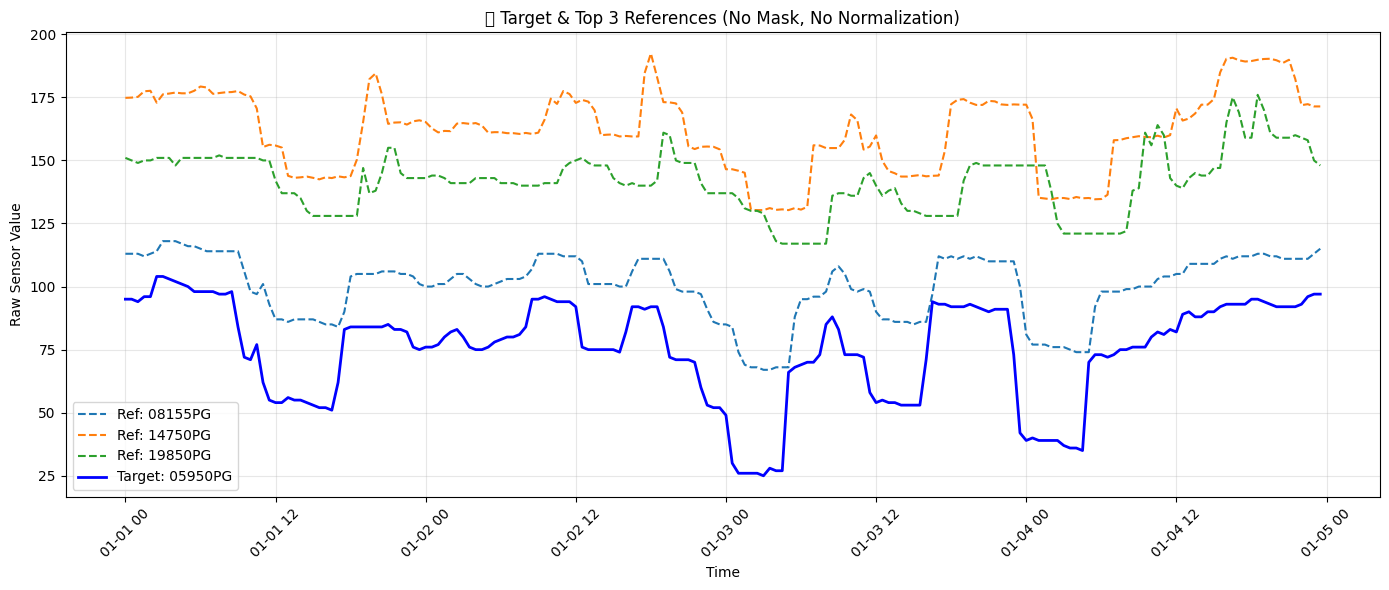

In [44]:
# Define the stations 
target = "05950PG"  # Target station
# References are the top 3 correlated stations
references = ["08155PG","14750PG","19850PG"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14587, 4)


station_code,05950PG,08155PG,14750PG,19850PG
timestamp,,,,
2023-01-01 00:00:00,1.368504,1.274192,0.831738,0.562487
2023-01-01 00:30:00,1.368504,1.274192,0.835961,0.511641
2023-01-01 01:00:00,1.330933,1.274192,0.848627,0.460796
2023-01-01 01:30:00,1.406074,1.223446,0.941515,0.511641
2023-01-01 02:00:00,1.406074,1.274192,0.949959,0.511641


In [46]:
# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the middle
# ---------------------------------------------------------

def inject_single_point_middle(series: pd.Series, missing_ratio: float = 0.10, middle_fraction: float = 0.5, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly in the middle region of the series (e.g., middle 50%).

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of points to mask (default = 0.1).
        middle_fraction (float): Fraction of series considered as "middle" (default = 0.5 = 50%).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with NaNs injected.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    mid_start = int(n * (1 - middle_fraction) / 2)
    mid_end = int(n * (1 + middle_fraction) / 2)

    candidate_indices = np.arange(mid_start, mid_end)
    n_missing = int(len(candidate_indices) * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(candidate_indices, size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


In [47]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply single to the normalized target series
# ---------------------------------------------------------

# Define target station 
target_station = "05950PG"


# Apply the masking function for a single missing value in the middle
masked_target, missing_indices, true_vals = inject_single_point_middle(
    normalized_df[target_station], missing_ratio=0.10
)

# ✅ Optional: Print info about the missing point
print("🔢 Injected missing indices:", missing_indices)
print("📉 True values:", true_vals[:5])  # preview first 5
print("🕓 Corresponding timestamps:", normalized_df.index[missing_indices[:5]])

🔢 Injected missing indices: [ 7555  9649  5414  7006  8346  4511  9882  5879  5366  5308  5212  8787
 10041 10819  9993  9928 10064  4409  6943  6300  5835  7591  9651  4843
  4075  7917  7551  5962  8230 10730  5638 10884  4200  5551  5680  4861
  5261  4648  6034  9646  5179  8972  6410 10347  4142  6337 10857  9473
  9576  4474  7198  3707  5075  6616  7601  7767  7196  8835  4111  9311
 10596  7876  9790  5548  3831  6308  4578 10361  9155  5133  4730 10767
 10932  6585  5586  9126  6914  5349 10026  6890  8084  9194  7709  8915
 10735  6364  5386  8669  7640  3747  8151  4382 10755  4184  8166  8799
  4379  8864  3725  9453  6759  8924  6728  8585  3778  4383  4687  5741
 10058 10493  5280 10070  9923 10522 10252  6954  8372  8887  8758  6293
  6785  8885  3965  9502 10543  4488  5540  3823  8809  8317  7478  7607
  5155 10299  5823  7317  5401  5891  6839  4684  9186  7096  9647  7079
  6648  6162  7344  5691  7885  8356  5374  6965  9017  6417  8198  7025
  7503  9080  7750 1042

In [48]:
# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

# 5️⃣ Get the indices of missing values
missing_indices = np.where(np.isnan(masked_target_array))[0]
true_vals = true_target_array[missing_indices]

# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)
print("❓ Missing indices (preview):", missing_indices[:5])
print("🔍 True values at missing indices (preview):", true_vals[:5])

🎯 Target shape: (14587,)
📘 Ref matrix shape: (3, 14587)
❓ Missing indices (preview): [3663 3665 3677 3683 3687]
🔍 True values at missing indices (preview): [-1.03602534 -1.37416221 -1.41173297 -0.09675624 -0.09675624]


In [49]:
# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

k = 5  # Number of top matching sequences (for TKCM-based methods)
l = 7  # Sliding window size for pattern matching (should be ≤ sequence length)

# 🧠 For matrix factorization-based methods (e.g., SVD, TRMF)
# Set a safe low-rank approximation based on the number of reference series
num_references = ref_matrix.shape[0]
rank = max(1, min(num_references - 1, 5))  # You can increase 2 → 5 for better modeling if safe



In [50]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


In [51]:
# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------



# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------
# TKCM-based Methods
# -------------------

# 1️⃣ TKCM
tkcm_imputed = masked_target_array.copy()
tkcm_model = TKCM(k=k, l=l)
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_imputed = masked_target_array.copy()
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_imputed = masked_target_array.copy()
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_imputed = masked_target_array.copy()
tkcm_pro_model = TKCM_PRO(k=k, l=l)
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------
# Matrix Factorization Models
# --------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# --------------------
# Simple Baseline Models
# --------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [52]:

results_point = []

# ✅ New helper to evaluate predictions at multiple missing indices
def evaluate_pointwise(name, imputed_array, true_values, missing_indices):
    try:
        predicted_vals = imputed_array[missing_indices]
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("Contains NaN")
        
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))
        
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


In [53]:
# Step 1: Stack masked target + reference
X_stmv = np.vstack([masked_target_array, ref_matrix])

# Step 2: Remove NaNs in references (only in reference rows)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])

# Step 3: Run ST_MVL and evaluate at missing indices
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # Only take imputed target row
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)
except Exception as e:
    print("❌ ST_MVL failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)



In [54]:
# Step 1: Prep TRMF input (shape = time x features)
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()

# Step 2: Generate mask and fill missing
observed_mask = ~np.isnan(X_trmf_input)
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3: Fit & transform
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    trmf_imputed = X_trmf_output[:, 0]  # First column is the target
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print("❌ TRMF failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


In [55]:
# ✅ TKCM Variants — loop over all, support multiple missing
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        # Impute once for all missing values (if supported)
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed:", e)
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)

# ✅ Baseline Models (already computed externally)
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ✅ Evaluate all models
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)

# ✅ Final Results Table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Points,MAE,RMSE
0,ST_MVL,729,0.500100,0.667000
1,TRMF,729,0.642500,0.737600
2,TKCM,729,0.130500,0.211300
3,TKCM_PLUS,729,0.730500,0.953300
4,TKCM_Weighted,729,0.129300,0.210600
5,TKCM_PRO,729,1.691400,2.135800
6,CDRec,729,0.185100,0.252700
7,DynaMMo,729,0.183500,0.251200
8,SoftImpute,729,0.177400,0.238100
9,SVDImpute,729,0.185300,0.253900


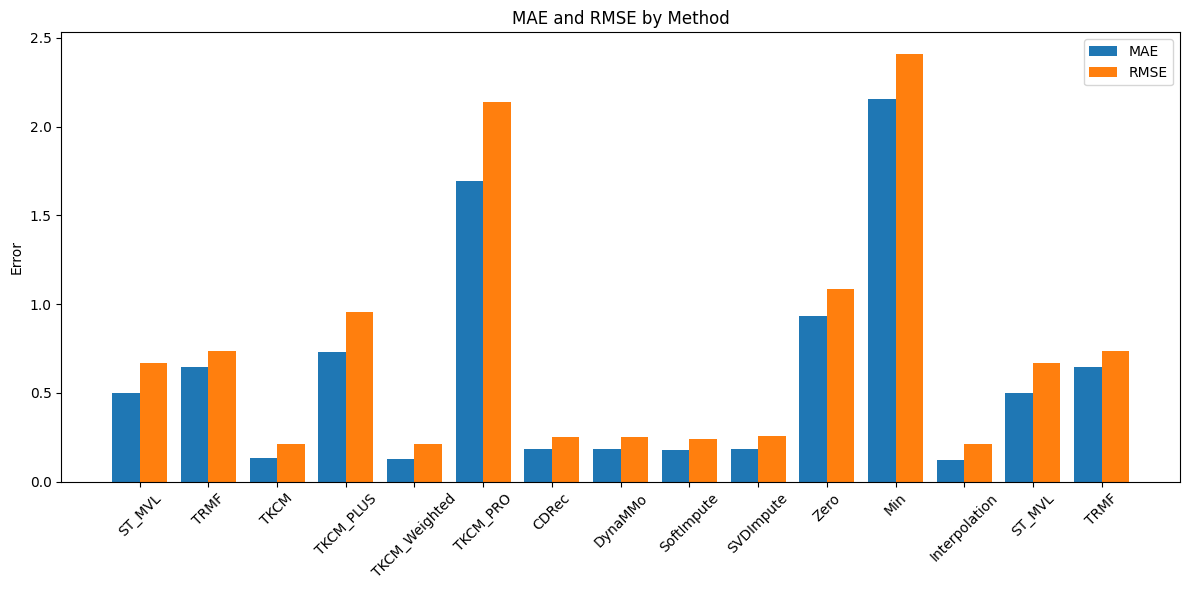

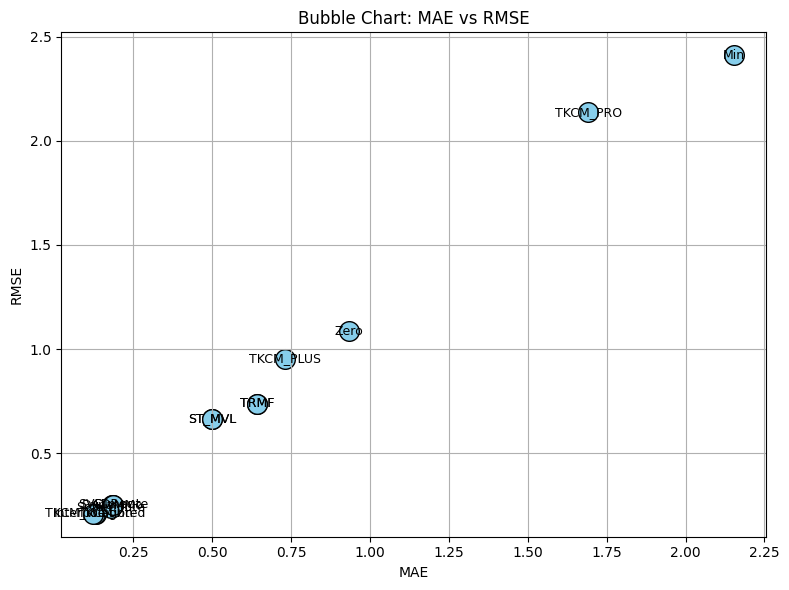

In [56]:
# Convert results_point to DataFrame for plotting
results_df = pd.DataFrame(results_point)

# Filter out methods with valid numeric values
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# ------------------------
# 📊 Bar Plot: MAE & RMSE
# ------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45)
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 🔵 Bubble Plot: MAE vs RMSE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["MAE"], plot_df["RMSE"],
                     s=200, c='skyblue', edgecolors='black')

# Annotate each point
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9,
                ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()


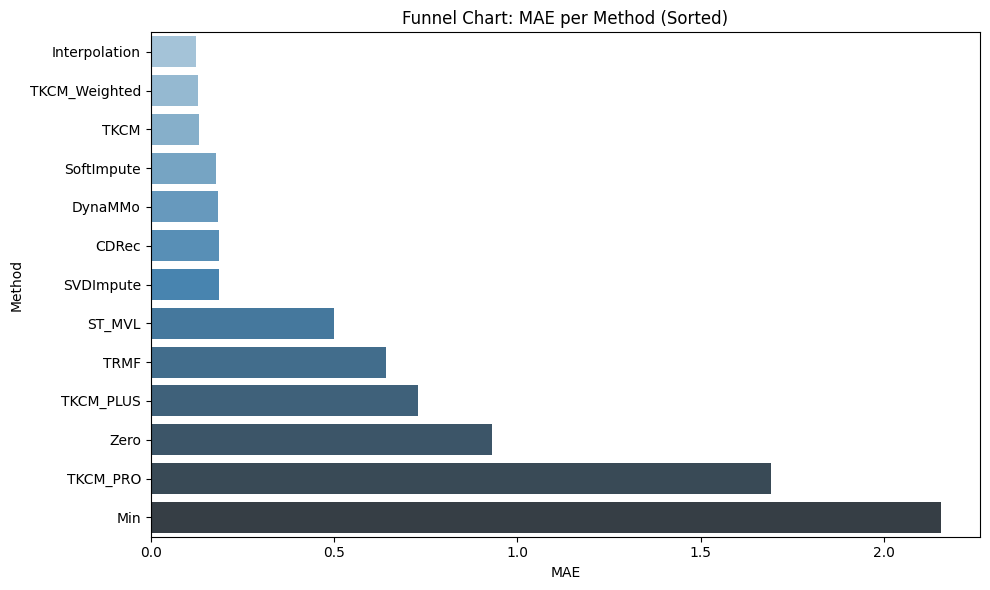

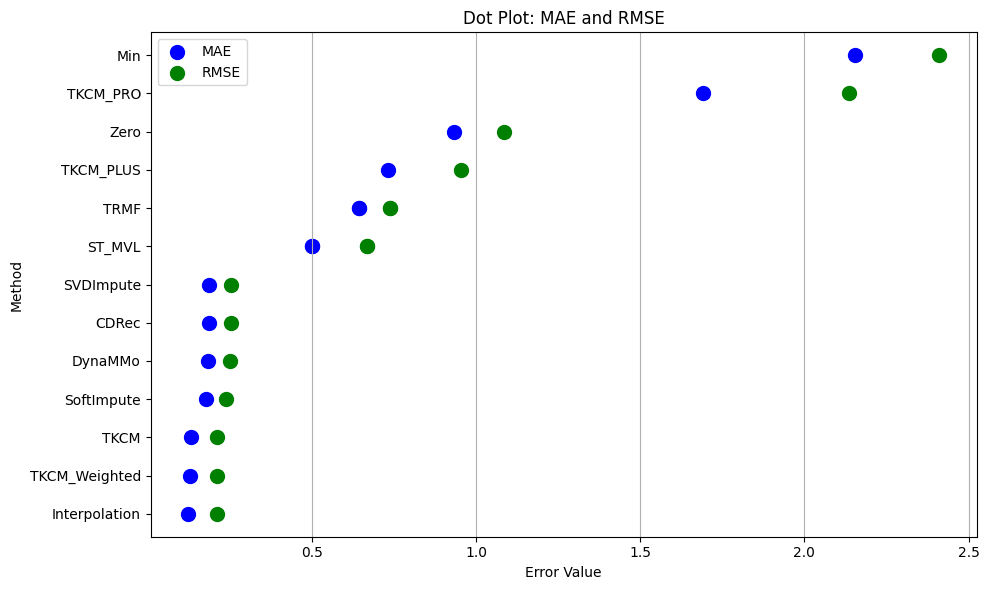

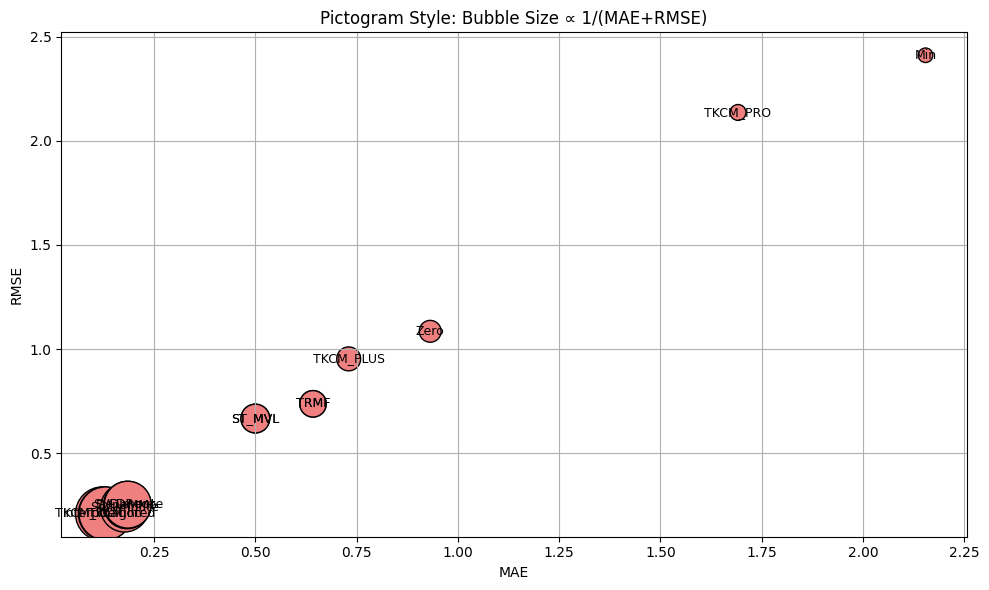

In [57]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use existing plot_df from previous context
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# Sort by MAE for consistent plotting
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# --------------------------------------
# 📉 Funnel Plot: Sorted MAE per Method
# --------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)")
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# ------------------------------
# 🎯 Dot Plot: MAE & RMSE Values
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)
plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ---------------------------------
# 📦 Pictogram: Bubble-like Visual
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])  # Inverse error = bigger is better

ax.scatter(plot_df["MAE"], plot_df["RMSE"], s=sizes, color='lightcoral', edgecolors='black')

for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1/(MAE+RMSE)")
plt.grid(True)
plt.tight_layout()
plt.show()
